# Chladni cymatics — mode schemes, D4 symmetry, sand particles

`biotuner.harmonic_geometry.media.eigenmode.RigidPlate` now exposes four
mode schemes, two D4 symmetry options, and a Gaussian-of-zero-crossing
density transform — together they reproduce the iconic Chladni sand
patterns from integer-ratio chord inputs.

This notebook walks through every option in order:

1. **`mode_scheme`** — `per_ratio` (classical), `pairwise_antisymmetric`
   (the iconic Chladni form), `pairwise_symmetric`, `triple_antisymmetric`.
2. **`symmetry`** — `none`, `d4_max` (non-linear, lattice-preserving),
   `d4_sum` (linear, smoother).
3. **`output` + `sigma`** — raw field vs `nodal_density` vs
   `antinodal_density` (the `exp(-w² / σ²)` transform).
4. **`Granular(nodal_emphasis=True)`** — sand-grain particle rendering
   on top of any field, the most photographic of the lot.
5. **`plotting.animate_chord_sequence`** — cosine-eased chord-to-chord
   morph that drives any of the above and renders an MP4.

All cymatics schemes use the chord's **integer-ratio** representation —
extracted losslessly via `chord_to_int_modes` (LCM of the `Fraction`
denominators). No rounding.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting
from biotuner.harmonic_geometry.media import RigidPlate, Granular, Pipeline
from biotuner.harmonic_geometry.media.eigenmode.rigid_plate import (
    chord_to_int_modes, chladni_field_pairwise, chladni_nodal_density,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## 1. Integer chord ratios — lossless

`chord_to_int_modes` multiplies through by the LCM of the denominators.
No rounding, no `limit_denominator` truncation. Each chord becomes its
smallest integer representation:

In [2]:
for name, c in CHORDS.items():
    int_form = chord_to_int_modes(c.to_ratios())
    print(f"  {name:6s}  Fraction form = {[str(r) for r in c.to_ratios()]}  "
          f"→ ints = {int_form}")


## 2. The four `mode_scheme` options

All four schemes are eigenmode-family operators on a rectangular plate.
The classical `per_ratio` scheme assigns one Stern-Brocot mode pair to
each ratio. The cymatics schemes sum modes over **pairs** (or **triples**)
of ratios — emphasizing the harmonic *relationships* in the chord rather
than the individual partials.

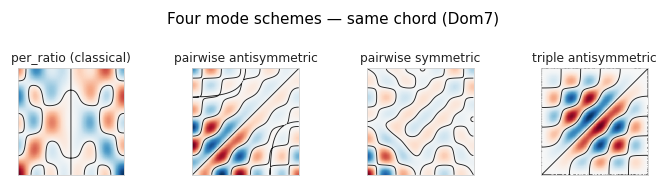

In [3]:
def _plate(scheme, **kw):
    return RigidPlate(mode_scheme=scheme, resolution=300, **kw)

dom7 = CHORDS["Dom7"]
geoms = [
    _plate("per_ratio")(dom7),
    _plate("pairwise_antisymmetric")(dom7),
    _plate("pairwise_symmetric")(dom7),
    _plate("triple_antisymmetric")(dom7),
]
plotting.gallery(
    geoms, n_cols=4,
    titles=["per_ratio (classical)",
            "pairwise antisymmetric",
            "pairwise symmetric",
            "triple antisymmetric"],
    suptitle="Four mode schemes — same chord (Dom7)",
);


## 3. D4 symmetrisation — `none` / `d4_max` / `d4_sum`

The dihedral-group D4 has 8 elements (4 rotations × 2 reflections).

- **`none`** — leave the field as-is.
- **`d4_max`** — element-wise *maximum* over the 8-orbit. Non-linear
  symmetrizer; preserves bright features → crystalline lattice look.
  This is what the original cymatics demo used.
- **`d4_sum`** — orbit *average*. Linear, smoother; enforces strict D4
  symmetry without amplifying any one orientation.


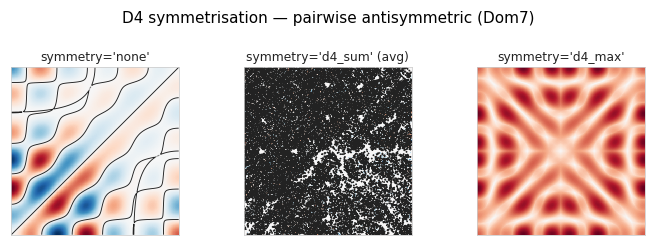

In [4]:
geoms = [
    _plate("pairwise_antisymmetric", symmetry="none")(dom7),
    _plate("pairwise_antisymmetric", symmetry="d4_sum")(dom7),
    _plate("pairwise_antisymmetric", symmetry="d4_max")(dom7),
]
plotting.gallery(
    geoms, n_cols=3,
    titles=["symmetry='none'", "symmetry='d4_sum' (avg)", "symmetry='d4_max'"],
    suptitle="D4 symmetrisation — pairwise antisymmetric (Dom7)",
);


## 4. `output='nodal_density'` — Gaussian of zero-crossing

The classical Chladni experiment shows sand **collecting on the nodal
lines** (where the plate displacement is zero). Mathematically this is
captured by the Gaussian-of-zero-crossing transform:

$$d(x, y) = \exp\!\left(-\frac{w(x, y)^2}{\sigma^2}\right)$$

`σ` controls the stripe width — small `σ` gives razor-thin nodes, large
`σ` gives wider soft bands.


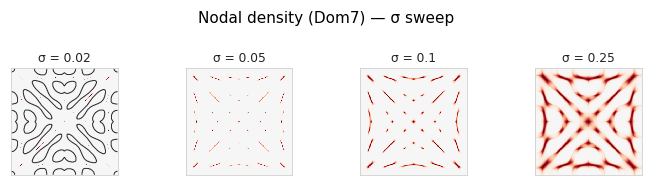

In [5]:
sigmas = [0.02, 0.05, 0.10, 0.25]
geoms = [
    _plate("pairwise_antisymmetric", symmetry="d4_max",
           output="nodal_density", sigma=s)(dom7)
    for s in sigmas
]
plotting.gallery(
    geoms, n_cols=4,
    titles=[f"σ = {s}" for s in sigmas],
    suptitle="Nodal density (Dom7) — σ sweep",
);


### Antinodal density

Setting `output='antinodal_density'` gives the *complement* — sand
accumulating on the **antinodes** (peaks and valleys) instead of the
nodes. A coral / fingerprint texture rather than the iconic lattice.

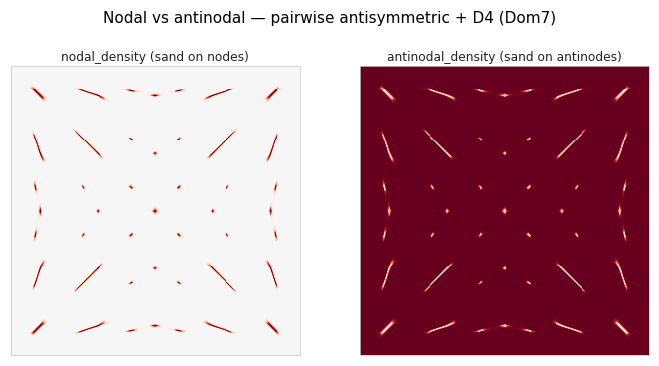

In [6]:
geoms = [
    _plate("pairwise_antisymmetric", symmetry="d4_max",
           output="nodal_density", sigma=0.05)(dom7),
    _plate("pairwise_antisymmetric", symmetry="d4_max",
           output="antinodal_density", sigma=0.05)(dom7),
]
plotting.gallery(
    geoms, n_cols=2,
    titles=["nodal_density (sand on nodes)", "antinodal_density (sand on antinodes)"],
    suptitle="Nodal vs antinodal — pairwise antisymmetric + D4 (Dom7)",
);


## 5. Same recipe across four chords

The full cymatics stack (pairwise antisymmetric + D4 max + nodal density)
gives a distinct fingerprint per chord — that's the visualization-as-
signature use case.

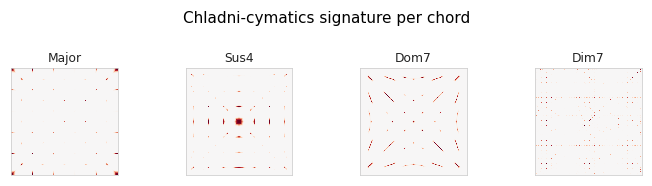

In [7]:
plate = _plate("pairwise_antisymmetric", symmetry="d4_max",
               output="nodal_density", sigma=0.05)
geoms = [plate(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, n_cols=4, titles=list(CHORDS.keys()),
                 suptitle="Chladni-cymatics signature per chord");


## 6. Sand-grain particles via `Granular(nodal_emphasis=True)`

The most photographic rendering: instead of an `imshow` of the density,
stochastically sample N particles from it and draw them as small white
dots on black. `Granular` now has a `nodal_emphasis=True` mode that
bypasses its Boltzmann formulation and uses `exp(-w² / σ²)` directly
on the incoming field — the standard Chladni-sand model. Compose any
field-producing medium with `Granular(output_mode='particles',
nodal_emphasis=True)`.


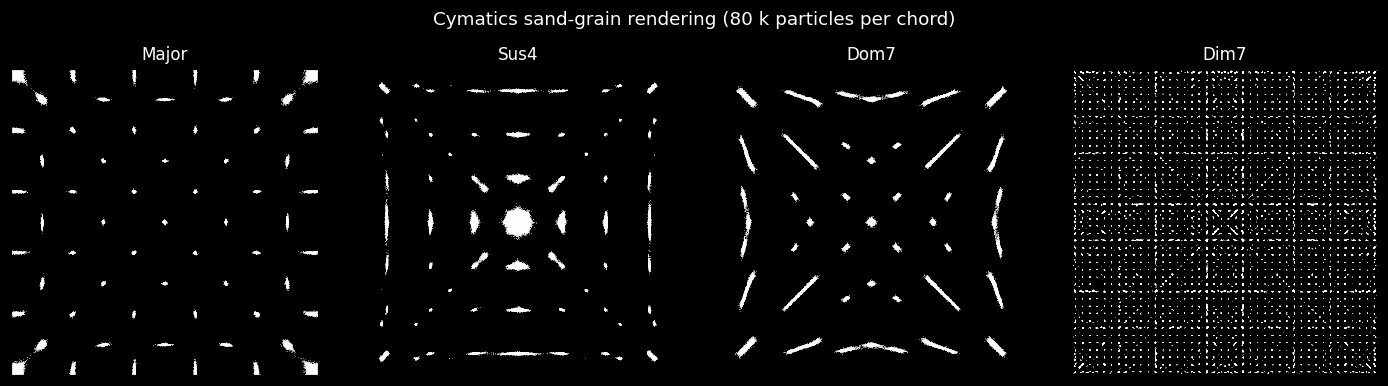

In [8]:
sand_pipeline = Pipeline(
    RigidPlate(mode_scheme="pairwise_antisymmetric",
               symmetry="d4_max", resolution=400),
    Granular(output_mode="particles", nodal_emphasis=True, sigma=0.05,
             n_particles=80_000, seed=0),
)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), facecolor="black")
for ax, (name, chord) in zip(axes, CHORDS.items()):
    pts = sand_pipeline(chord).coordinates
    ax.set_facecolor("black")
    ax.scatter(pts[:, 0], pts[:, 1], s=0.5, c="white", alpha=0.5,
               linewidths=0)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(name, color="white", fontsize=11)
fig.suptitle("Cymatics sand-grain rendering (80 k particles per chord)",
             color="white", y=1.02)
fig.tight_layout();


### Tuning the look — particles, sigma, plate side

A few quick visual handles:

- **`n_particles`** — density of the grain field (more grains = denser look).
- **`sigma`** — stripe width; smaller = razor-thin sand bands.
- **`Lx`/`Ly`** kept square (the D4 symmetrization requires it).


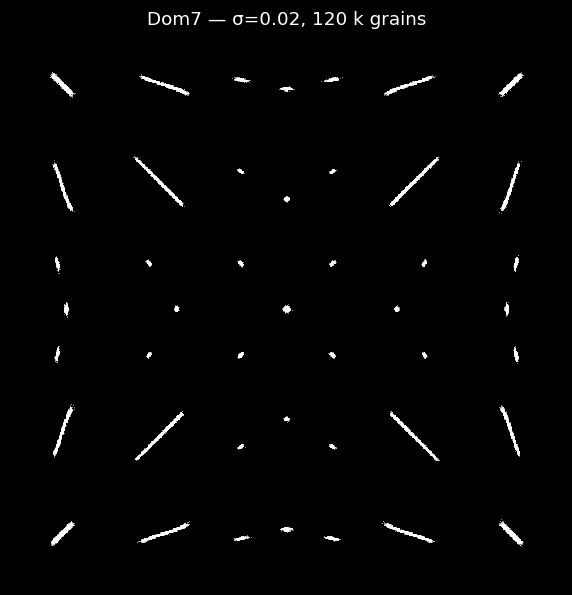

In [9]:
pipe_small = Pipeline(
    RigidPlate(mode_scheme="pairwise_antisymmetric",
               symmetry="d4_max", resolution=400),
    Granular(output_mode="particles", nodal_emphasis=True, sigma=0.02,
             n_particles=120_000, seed=0),
)
pts = pipe_small(CHORDS["Dom7"]).coordinates
fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="black")
ax.set_facecolor("black")
ax.scatter(pts[:, 0], pts[:, 1], s=0.5, c="white", alpha=0.6, linewidths=0)
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Dom7 — σ=0.02, 120 k grains", color="white");


## 7. Triple-antisymmetric — for chords of ≥3 ratios

The triple-antisymmetric scheme sums the **cyclic chain** of pair-modes
over every distinct triple in the chord:

$$M(a, b) + M(b, c) + M(c, a)\quad\text{for each (a,b,c)} \subset \text{chord}$$

where $M(p, q) = \cos(p\pi X)\cos(q\pi Y) - \cos(q\pi X)\cos(p\pi Y)$.
This emphasises *triadic* interactions: a triadic chord contributes one
rich three-fold-flavoured mode rather than the three independent pair
modes that the pairwise scheme would otherwise emit.


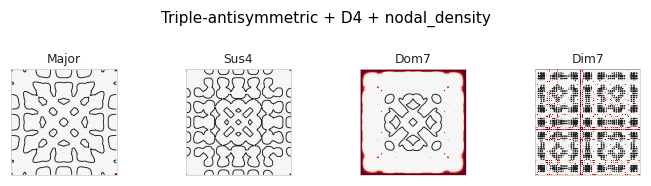

In [10]:
plate_tri = _plate("triple_antisymmetric", symmetry="d4_max",
                   output="nodal_density", sigma=0.05)
geoms = [plate_tri(CHORDS[n]) for n in CHORDS]  # Major has 3 ratios — works
plotting.gallery(geoms, n_cols=4, titles=list(CHORDS.keys()),
                 suptitle="Triple-antisymmetric + D4 + nodal_density");


## 8. Animation — chord-sequence morph

`plotting.animate_chord_sequence` drives any chord→geometry builder
through a cosine-eased loop. Each chord is an integer-ratio list (or a
floats list — mid-segment frames receive interpolated values).

The cell below renders a 6-second MP4 (3 chord segments × 48 frames at
24 fps). The file is saved next to the notebook and is *not* displayed
inline — open it locally to play.


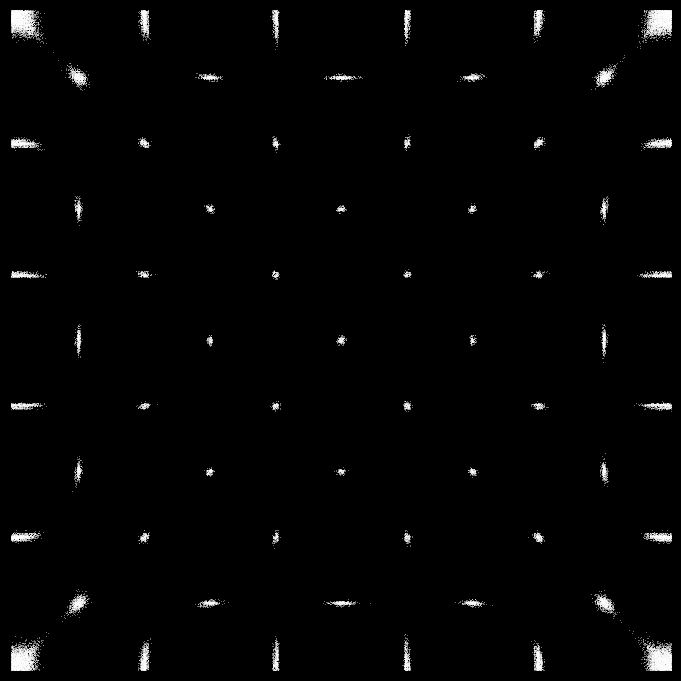

In [11]:
from biotuner.harmonic_geometry.media.eigenmode.rigid_plate import (
    chladni_field_pairwise,
)

# Chord keyframes — integer-ratio form straight from chord_to_int_modes,
# or any small-int list. Each chord must have the same length for
# component-wise interpolation.
CHORD_KEYFRAMES = [
    chord_to_int_modes(CHORDS["Major"].to_ratios()),  # [4, 5, 6]
    chord_to_int_modes(CHORDS["Sus4"].to_ratios()),   # [6, 8, 9]
    chord_to_int_modes(CHORDS["Major"].to_ratios()),  # back to Major
]
print("keyframes:", CHORD_KEYFRAMES)

def cymatics_builder(chord):
    field = chladni_field_pairwise(
        list(chord), resolution=240, symmetry="d4_max",
    )
    sand = Granular(
        output_mode="particles", nodal_emphasis=True, sigma=0.05,
        n_particles=40_000, seed=0,
    )(field)
    return sand

import os
os.makedirs("renders", exist_ok=True)
anim = plotting.animate_chord_sequence(
    CHORD_KEYFRAMES, cymatics_builder,
    frames_per_segment=24, fps=24, loop=True,
    figsize=(6.0, 6.0),
    save_path="renders/chladni_morph_demo.mp4",
    dpi=100,
)
print("rendered:", os.path.getsize("renders/chladni_morph_demo.mp4"), "bytes")


## Recipe quick reference

| Want | Configuration |
|---|---|
| classical biotuner Chladni (default) | `RigidPlate()` |
| iconic square-plate Chladni lattice | `RigidPlate(mode_scheme="pairwise_antisymmetric", symmetry="d4_max")` |
| sand-on-the-nodes density field | add `output="nodal_density", sigma=0.05` |
| sand-grain photographic look | `Pipeline(plate, Granular(output_mode="particles", nodal_emphasis=True, sigma=0.05, n_particles=80_000))` |
| triadic mode flavour | `mode_scheme="triple_antisymmetric"` (needs ≥3 ratios) |
| smooth D4 averaging | `symmetry="d4_sum"` instead of `"d4_max"` |
| chord-to-chord morph MP4 | `plotting.animate_chord_sequence([chord1, chord2, …], builder, save_path=…)` |
